In [1]:
import mysql.connector  
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt 
import numpy as np
import scipy.stats as stats

conn = mysql.connector.connect(
    host="192.168.0.4",     # MySQL 서버 주소
    user="farmorai_admin", # MySQL 사용자명
    password="farmorai12345", # MySQL 비밀번호
    database="farmdb"  # 사용할 데이터베이스 이름
)

In [3]:
query = "SELECT cate3, weight, height, width FROM apple_label_dataset"
df = pd.read_sql(query, conn)
grade_map = {"특": 2, "상": 1, "보통": 0}
df["cate3"] = df["cate3"].map(grade_map)

# ✅ 부피 계산
df["volume"] = (4/3) * np.pi * (df["width"] / 2) ** 2 * (df["height"] / 2)

# ✅ 변환된 데이터 확인
print(df)

       cate3  weight  height  width      volume
0          2   348.0     8.8    8.8  356.817905
1          2   348.0     8.8    8.8  356.817905
2          2   348.0     8.8    8.8  356.817905
3          2   348.0     8.8    8.8  356.817905
4          2   348.0     8.8    8.8  356.817905
...      ...     ...     ...    ...         ...
10943      0   273.0     7.1    9.1  307.850424
10944      0   273.0     7.1    9.1  307.850424
10945      0   273.0     7.1    9.1  307.850424
10946      0   273.0     7.1    9.1  307.850424
10947      0   200.0     6.5    7.5  191.440802

[10948 rows x 5 columns]


C:\Users\KOSMO\AppData\Local\Temp\ipykernel_4472\224187737.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
print(df.describe())

              cate3        weight        height         width        volume
count  10948.000000  10948.000000  10948.000000  10948.000000  10948.000000
mean       0.999909    297.230727      7.696693      8.748785    311.562915
std        0.816553     54.283838      0.650939      0.582805     58.682700
min        0.000000    185.000000      6.200000      7.100000    182.122839
25%        0.000000    259.000000      7.200000      8.400000    270.530397
50%        1.000000    284.000000      7.600000      8.800000    305.362806
75%        2.000000    341.000000      8.200000      9.200000    359.881481
max        2.000000    450.000000      9.400000     10.500000    519.540885


In [ ]:
plt.figure(figsize=(10, 6))

colors = ["blue", "orange", "green"]  # 각 등급별 색상 지정
labels = ["보통 (0)", "상 (1)", "특 (2)"]

for i, grade in enumerate([0, 1, 2]):
    data = df[df["cate3"] == grade]["weight"]
    
    # KDE 그래프
    sns.kdeplot(data, label=f"{labels[i]}", fill=True, common_norm=False, color=colors[i])
    
    # 정규분포 피팅
    mu, std = stats.norm.fit(data)
    x = np.linspace(min(data), max(data), 100)
    y = stats.norm.pdf(x, mu, std)
    
    # 정규분포 곡선 추가
    plt.plot(x, y, linestyle="dashed", color=colors[i], label=f"{labels[i]} (정규분포)")

# ✅ 그래프 설정
plt.xlabel("무게 (g)")
plt.ylabel("밀도 (Density)")
plt.title("등급별 사과 무게 분포 (KDE & 정규분포)")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\KOSMO\.conda\envs\dahye_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KOSMO\.conda\envs\dahye_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KOSMO\.conda\envs\dahye_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KOSMO\.conda\envs\dahye_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54021 (\N{HANGUL SYLLABLE TING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


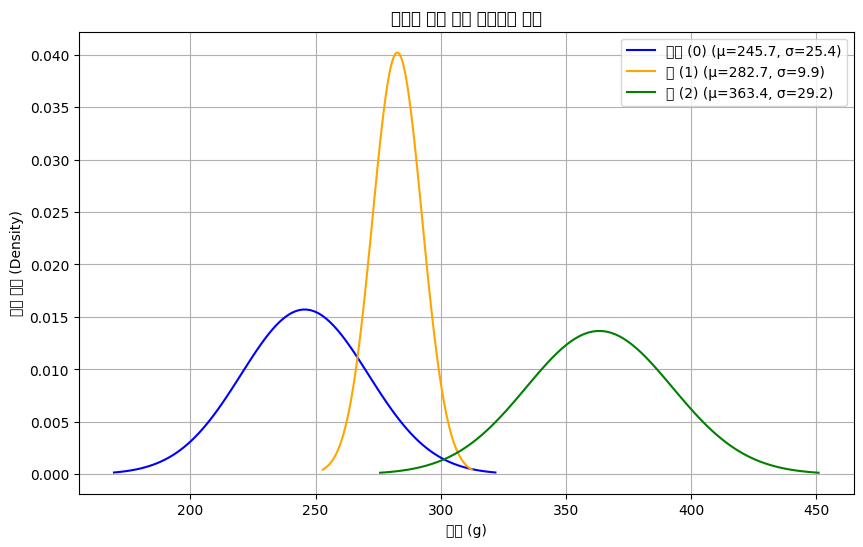

In [6]:
plt.figure(figsize=(10, 6))

colors = ["blue", "orange", "green"]  # 등급별 색상
labels = ["보통 (0)", "상 (1)", "특 (2)"]

for i, grade in enumerate([0, 1, 2]):
    data = df[df["cate3"] == grade]["weight"]
    
    # ✅ 정규분포 피팅
    mu, std = np.mean(data), np.std(data)  # 평균과 표준편차 계산
    x = np.linspace(mu - 3*std, mu + 3*std, 100)  # X축 범위 설정 (±3σ)
    y = stats.norm.pdf(x, mu, std)  # 정규분포 확률 밀도 함수 계산
    
    # ✅ 정규분포 곡선 그래프
    plt.plot(x, y, label=f"{labels[i]} (μ={mu:.1f}, σ={std:.1f})", color=colors[i])

# ✅ 그래프 스타일링
plt.xlabel("무게 (g)")
plt.ylabel("확률 밀도 (Density)")
plt.title("등급별 사과 무게 정규분포 피팅")
plt.legend()
plt.grid(True)
plt.show()